# __Modelo Base: Desicion Tree Classifier__

## __Objetivo__

Encontrar un modelo que detecte clientes en riesgo de cancelar el servicio con la empresa.

## __Importar librerias__

In [42]:
import sys
sys.path.append('../src')

In [43]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
from imblearn.under_sampling import NearMiss

from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, precision_recall_curve

import importlib
import utils

importlib.reload(utils)
from utils import plot_mat_confusion, cv_score_interval, metricas_evaluacion

## __Cargar datos__

In [44]:
X_cv = pd.read_csv('../out/df/X_cv.csv', index_col=0)
y_cv = pd.read_csv('../out/df/y_cv.csv', index_col=0)
X_test = pd.read_csv('../out/df/X_test.csv', index_col=0)
y_test = pd.read_csv('../out/df/y_test.csv', index_col=0)

## __Analisis de validacion cruzada__

Aplicar la validacion cruzada al modelo base utilizando los datos _df_. Luego, calculamos un intervalo de confianza del 95% para una metrica de evaluacion (por defecto, el Recall) obtenido con la funcion _cv_score_interval_. Esto ayuda a entender la variabilidad del desempeno del modelo y en que rango se espera que se encuentre la metrica seleccionada.

In [45]:
# 6 particiones. Mezcla los datos antes de dividirlos
skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)

# instanciar modelo base. Profundidad de 10
baseline_model = DecisionTreeClassifier(max_depth=10, random_state=42)

# Validacion cruzada estratificada. Calcular recall como metrica de desempeno
baseline_cross_val_results = cross_validate(baseline_model, X_cv, y_cv, cv=skf, scoring='recall')

cv_score_interval(
    results=baseline_cross_val_results,
    nombre='Modelo Base',
    score='Recall'
    )

Recall promedio de Modelo Base: 0.5236
Desviación estándar del Recall de Modelo Base: 0.0426
El Recall de Modelo Base estará entre [0.4384,0.6088] con un 95% de confianza


> El modelo base identifica alrededor 52.36% de los casos en los que los clientes cancelan.

> La desviacion estandar es baja, lo que indica que el modelo es estable.

> Con un 95% de confianza, el verdadero recall del modelo al probarlo con nuevos datos estara entre 43.8% y 60.8%. Un rango muy amplio ue se puede mejorar

## __Entrenamiento y evaluacion del modelo__

Entrenamos el modelo con los datos de entrenamiento de _df_

In [46]:
baseline_model.fit(X_cv, y_cv)

DecisionTreeClassifier(max_depth=10, random_state=42)

Generar un reporte detallado del modelo usando el conjunto de prueba

In [47]:
baseline_pred = baseline_model.predict(X_test)
print(classification_report(y_test, baseline_pred))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       775
           1       0.56      0.51      0.53       280

    accuracy                           0.76      1055
   macro avg       0.69      0.68      0.69      1055
weighted avg       0.76      0.76      0.76      1055



__Clase 0 (Clientes que permanecen con la empresa)__

> Cuando el modelo predice que un cliente permanece, acierta el 84% de las veces (Precision 0.83).

> Detecta correctamente al 85% de los clientes que permanecen (Recall 0.85).

> Es una clase con un buen equilibrio entre precision y recall (F1-score 0.84).

> 775 clientes permanecen con la empresa y son la mayoria.

__Clase 1 (Clientes que cancelan el servicio con la empresa)__

> Cuando el modelo predice que un cliente cancelara, acierta solo el 56% de las veces.

> Captura correctamente el 51% de los clientes que cancelan (Recall 0.51).

> Es una clase con un balance moderado entre precision y recall (F1-score 0.53).

> 280 clientes cancelan el servicio con la empresa.

__Metricas Generales__
> El modelo acierta en el 76% de los casos. Debido a que las clases estan desbalanceadas, esta metrica puede estar influenciada por la clase mayoritaria.

## __Visualizacion del desempeno del modelo__

Graficar la matriz de confusion del modelo base para mejorar la visualizacion e interpretabilidad de los resultados. Para ello, usamos la funcion _plot_mat_confusion_

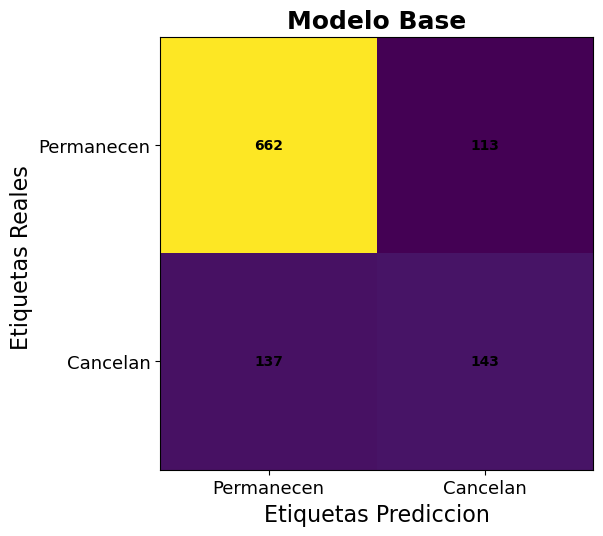

In [48]:
plot_mat_confusion(baseline_model, X_test, y_test, 'Modelo Base')

Obtener las metricas relevantes del modelo base con la funcion 'metricas_evaluacion'

In [49]:
metricas_evaluacion(
    modelo=baseline_model,
    x_test=X_test,
    y_test = y_test,
    nombre='Modelo Base',
    conjunto='X'
    )

{'Model': 'Modelo Base',
 'Dataset': 'X',
 'Accuracy': np.float64(0.763),
 'Precision': np.float64(0.5586),
 'Recall': np.float64(0.5107),
 'F1-score': np.float64(0.5336),
 'AUC': np.float64(0.7466),
 'Umbral': 0.5}

> El modelo acierta el 76.3% de las predicciones totales (Accuracy).

> El 55.86% de las veces que el modelo predice que un cliente cancela el servicio, acierta.

> El modelo logra detectar el 51% de los clientes que efectivamente cancelan

> Un 53.3% en F1-score indica un balance regular entre presicion y recall.

> El modelo distingue correctamente entre ambas clases en un 74.6% de los casos.

> Se uso un unmbral estandar de 0.5 para clasificar.

Basado en el objetivo del proyecto, vamos a mejorar la sensibilidad del modelo sin sacrificar excesivamente la precision ya que demasiados errores en precision puede llevar a campanas de retencion ineficientes en costos (intervenciones innecesarias sobre clientes que continuaran con la empresa)

## __Curva ROC__

El AUC-ROC mide que tan bien un modelo distingue entre clases binarias. La curva ROC muestra el compromiso entre sensibilidad y tasa de falsos positivos a diferentes umbrales de clasificacion

- El eje X mide cuantos negativos fueron clasificados incorrectamente como positivos.

- El eje Y mide cuantos positivos reales fueron correctamente detectados.

- Si AUC se acerca a 1, el modelo predice correctamente todas las instancias.

- Si AUC = 0.5 el modelo no tiene poder predictivo.

- Si AUC es menor a 0.5, el modelo invierte las predicciones.

Generar la curva ROC para obtener el umbral optimo de decision.

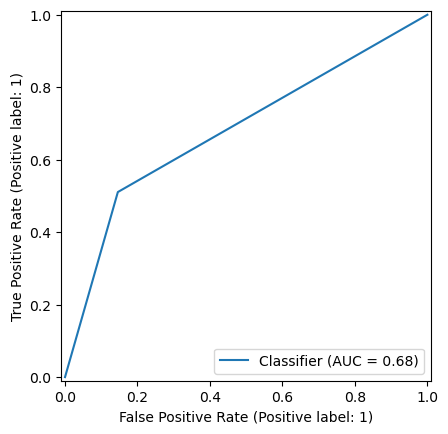

In [50]:
RocCurveDisplay.from_predictions(y_test, baseline_pred);